In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, f1_score
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

FEATURES_DIR = Path('../../data/features')
MODELS_DIR = Path('../../data/models')

print('Imports OK')

Imports OK


In [2]:
df = pd.read_parquet(FEATURES_DIR / 'feature_matrix_v2.parquet')
with open(FEATURES_DIR / 'feature_meta_v2.json') as f:
    meta = json.load(f)

with open(MODELS_DIR / 'model_meta_v1.json') as f:
    model_meta = json.load(f)

FEATURES = model_meta['features']
train_medians = np.array(model_meta['train_medians'])

df_bin = df[df['label'] != 0].copy()
df_bin['y'] = (df_bin['label'] == 1).astype(int)
df_bin = df_bin.sort_values('t0').reset_index(drop=True)

n = len(df_bin)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df_bin.iloc[:train_end]
val = df_bin.iloc[train_end:val_end]
test = df_bin.iloc[val_end:]

X_train, y_train = train[FEATURES].values, train['y'].values
X_val, y_val = val[FEATURES].values, val['y'].values
X_test, y_test = test[FEATURES].values, test['y'].values

for i in range(X_train.shape[1]):
    X_train[np.isnan(X_train[:, i]), i] = train_medians[i]
    X_val[np.isnan(X_val[:, i]), i] = train_medians[i]
    X_test[np.isnan(X_test[:, i]), i] = train_medians[i]

with open(MODELS_DIR / 'xgb_best_params.json') as f:
    xgb_params = json.load(f)
with open(MODELS_DIR / 'lgb_best_params.json') as f:
    lgb_params = json.load(f)

xgb_params.update({'objective': 'binary:logistic', 'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})
lgb_params.update({'objective': 'binary', 'random_state': SEED, 'n_jobs': -1, 'verbose': -1})

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

print(f'Data: {len(df_bin):,} samples, {len(FEATURES)} features')
print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')
print(f'XGB val AUC: {roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1]):.4f}')
print(f'LGB val AUC: {roc_auc_score(y_val, lgb_model.predict_proba(X_val)[:, 1]):.4f}')

Data: 35,083 samples, 63 features
Train: 24,558 | Val: 5,262 | Test: 5,263
XGB val AUC: 0.6953
LGB val AUC: 0.6931


In [3]:
from sklearn.isotonic import IsotonicRegression

def calibrate_platt(y_true, y_prob_train, y_prob_test):
    """Platt scaling: fit logistic regression on probabilities."""
    lr = LogisticRegression()
    lr.fit(y_prob_train.reshape(-1, 1), y_true)
    return lr.predict_proba(y_prob_test.reshape(-1, 1))[:, 1]

def calibrate_isotonic(y_true, y_prob_train, y_prob_test):
    """Isotonic regression calibration."""
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob_train, y_true)
    return iso.predict(y_prob_test)

xgb_prob_val = xgb_model.predict_proba(X_val)[:, 1]
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
lgb_prob_val = lgb_model.predict_proba(X_val)[:, 1]
lgb_prob_test = lgb_model.predict_proba(X_test)[:, 1]

xgb_platt_prob = calibrate_platt(y_val, xgb_prob_val, xgb_prob_test)
xgb_iso_prob = calibrate_isotonic(y_val, xgb_prob_val, xgb_prob_test)
lgb_platt_prob = calibrate_platt(y_val, lgb_prob_val, lgb_prob_test)
lgb_iso_prob = calibrate_isotonic(y_val, lgb_prob_val, lgb_prob_test)

platt_xgb = LogisticRegression()
platt_xgb.fit(xgb_prob_val.reshape(-1, 1), y_val)
platt_lgb = LogisticRegression()
platt_lgb.fit(lgb_prob_val.reshape(-1, 1), y_val)
iso_xgb = IsotonicRegression(out_of_bounds='clip')
iso_xgb.fit(xgb_prob_val, y_val)
iso_lgb = IsotonicRegression(out_of_bounds='clip')
iso_lgb.fit(lgb_prob_val, y_val)

cal_probs = {
    'XGB raw': xgb_prob_test,
    'XGB Platt': xgb_platt_prob,
    'XGB Isotonic': xgb_iso_prob,
    'LGB raw': lgb_prob_test,
    'LGB Platt': lgb_platt_prob,
    'LGB Isotonic': lgb_iso_prob,
}

print(f'{"Model":16s} | {"AUC":>8s} | {"LogLoss":>8s} | {"Brier":>8s} | {"Acc":>8s}')
print('-' * 65)

cal_results = {}
for name, y_prob in cal_probs.items():
    y_pred = (y_prob > 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)

    cal_results[name] = {'auc': auc, 'logloss': ll, 'brier': brier, 'accuracy': acc}
    print(f'{name:16s} | {auc:8.4f} | {ll:8.4f} | {brier:8.4f} | {acc:8.4f}')

Model            |      AUC |  LogLoss |    Brier |      Acc
-----------------------------------------------------------------
XGB raw          |   0.6767 |   0.6497 |   0.2282 |   0.6373
XGB Platt        |   0.6767 |   0.6462 |   0.2270 |   0.6382
XGB Isotonic     |   0.6758 |   0.6545 |   0.2294 |   0.6348
LGB raw          |   0.6777 |   0.6481 |   0.2274 |   0.6437
LGB Platt        |   0.6777 |   0.6456 |   0.2267 |   0.6435
LGB Isotonic     |   0.6771 |   0.6533 |   0.2288 |   0.6411


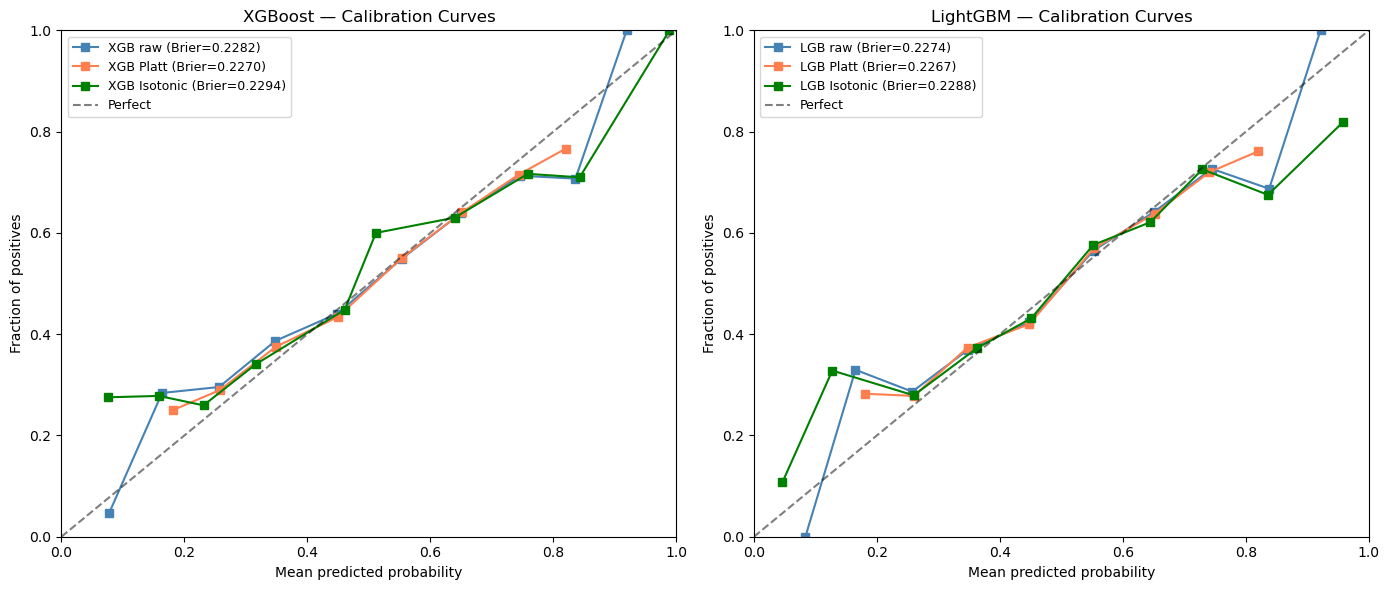


Best calibration: LGB Platt (Brier=0.2267)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, base_name, models_subset in [
    (axes[0], 'XGBoost', ['XGB raw', 'XGB Platt', 'XGB Isotonic']),
    (axes[1], 'LightGBM', ['LGB raw', 'LGB Platt', 'LGB Isotonic']),
]:
    colors = ['steelblue', 'coral', 'green']
    for name, color in zip(models_subset, colors):
        y_prob = cal_probs[name]
        fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
        brier = brier_score_loss(y_test, y_prob)
        ax.plot(mean_predicted, fraction_pos, 's-', label=f'{name} (Brier={brier:.4f})', color=color)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{base_name} — Calibration Curves')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'calibration_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

best_cal = min(cal_results.items(), key=lambda x: x[1]['brier'])
print(f'\nBest calibration: {best_cal[0]} (Brier={best_cal[1]["brier"]:.4f})')

In [5]:
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
lgb_prob_test = lgb_model.predict_proba(X_test)[:, 1]

avg_prob_test = (xgb_prob_test + lgb_prob_test) / 2
avg_pred_test = (avg_prob_test > 0.5).astype(int)

xgb_prob_val = xgb_model.predict_proba(X_val)[:, 1]
lgb_prob_val = lgb_model.predict_proba(X_val)[:, 1]

best_w, best_auc_w = 0.5, 0
for w in np.arange(0.0, 1.01, 0.05):
    blend_val = w * xgb_prob_val + (1 - w) * lgb_prob_val
    auc_w = roc_auc_score(y_val, blend_val)
    if auc_w > best_auc_w:
        best_w, best_auc_w = w, auc_w

weighted_prob_test = best_w * xgb_prob_test + (1 - best_w) * lgb_prob_test
weighted_pred_test = (weighted_prob_test > 0.5).astype(int)

print(f'Best weight: XGB={best_w:.2f}, LGB={1-best_w:.2f} (val AUC={best_auc_w:.4f})')

X_meta_val = np.column_stack([xgb_prob_val, lgb_prob_val])
X_meta_test = np.column_stack([xgb_prob_test, lgb_prob_test])

meta_lr = LogisticRegression(random_state=SEED)
meta_lr.fit(X_meta_val, y_val)
stack_prob_test = meta_lr.predict_proba(X_meta_test)[:, 1]
stack_pred_test = (stack_prob_test > 0.5).astype(int)

print(f'Stacking meta weights: XGB={meta_lr.coef_[0][0]:.3f}, LGB={meta_lr.coef_[0][1]:.3f}, bias={meta_lr.intercept_[0]:.3f}')

ens_models = {
    'XGB (base)': (xgb_prob_test, (xgb_prob_test > 0.5).astype(int)),
    'LGB (base)': (lgb_prob_test, (lgb_prob_test > 0.5).astype(int)),
    'Soft Voting': (avg_prob_test, avg_pred_test),
    'Weighted Avg': (weighted_prob_test, weighted_pred_test),
    'Stacking (LR)': (stack_prob_test, stack_pred_test),
}

print(f'\n{"Model":16s} | {"AUC":>8s} | {"LogLoss":>8s} | {"Brier":>8s} | {"Acc":>8s} | {"F1":>8s}')
print('-' * 75)

ens_results = {}
for name, (y_prob, y_pred) in ens_models.items():
    auc = roc_auc_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    ens_results[name] = {'auc': auc, 'logloss': ll, 'brier': brier, 'accuracy': acc, 'f1': f1}
    print(f'{name:16s} | {auc:8.4f} | {ll:8.4f} | {brier:8.4f} | {acc:8.4f} | {f1:8.4f}')

Best weight: XGB=0.65, LGB=0.35 (val AUC=0.6959)
Stacking meta weights: XGB=2.613, LGB=1.567, bias=-2.077

Model            |      AUC |  LogLoss |    Brier |      Acc |       F1
---------------------------------------------------------------------------
XGB (base)       |   0.6767 |   0.6497 |   0.2282 |   0.6373 |   0.6376
LGB (base)       |   0.6777 |   0.6481 |   0.2274 |   0.6437 |   0.6466
Soft Voting      |   0.6783 |   0.6478 |   0.2274 |   0.6401 |   0.6428
Weighted Avg     |   0.6781 |   0.6482 |   0.2275 |   0.6386 |   0.6407
Stacking (LR)    |   0.6781 |   0.6458 |   0.2268 |   0.6386 |   0.6421


In [6]:
def walk_forward_validation(df_sorted, features, train_days=60, test_days=7,
                            model_class=None, model_params=None):
    """Walk-forward validation with expanding window.

    Returns list of dicts with per-window metrics.
    """
    df_sorted = df_sorted.copy()
    dates = df_sorted['t0'].dt.date
    date_range = pd.date_range(dates.min(), dates.max(), freq='D')

    results = []

    start_date = date_range[0]
    first_test_date = start_date + pd.Timedelta(days=train_days)

    test_starts = pd.date_range(first_test_date, date_range[-1], freq=f'{test_days}D')

    for test_start in test_starts:
        test_end = test_start + pd.Timedelta(days=test_days)

        train_mask = dates < test_start.date()
        test_mask = (dates >= test_start.date()) & (dates < test_end.date())

        df_tr = df_sorted[train_mask]
        df_te = df_sorted[test_mask]

        if len(df_te) < 50:
            continue

        X_tr = df_tr[features].values
        y_tr = df_tr['y'].values
        X_te = df_te[features].values
        y_te = df_te['y'].values

        medians = np.nanmedian(X_tr, axis=0)
        for j in range(X_tr.shape[1]):
            X_tr[np.isnan(X_tr[:, j]), j] = medians[j]
            X_te[np.isnan(X_te[:, j]), j] = medians[j]

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)

        auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5
        acc = accuracy_score(y_te, y_pred)

        results.append({
            'test_start': test_start.date(),
            'test_end': test_end.date(),
            'train_size': len(df_tr),
            'test_size': len(df_te),
            'auc': auc,
            'accuracy': acc,
            'tp_rate': y_te.mean(),
        })

    return pd.DataFrame(results)

print('Walk-Forward Validation (LightGBM, expanding window, 7-day steps)...')
t0 = time.time()
wf_lgb = walk_forward_validation(
    df_bin, FEATURES,
    train_days=60, test_days=7,
    model_class=lgb.LGBMClassifier, model_params=lgb_params
)
elapsed = time.time() - t0

print(f'Completed {len(wf_lgb)} windows in {elapsed:.0f}s')
print(f'\nWalk-Forward Results:')
print(f'  AUC:      {wf_lgb["auc"].mean():.4f} ± {wf_lgb["auc"].std():.4f}')
print(f'  Accuracy: {wf_lgb["accuracy"].mean():.4f} ± {wf_lgb["accuracy"].std():.4f}')
print(f'  Test sizes: {wf_lgb["test_size"].min()} — {wf_lgb["test_size"].max()} (mean {wf_lgb["test_size"].mean():.0f})')
print(wf_lgb.to_string(index=False))

Walk-Forward Validation (LightGBM, expanding window, 7-day steps)...


Completed 5 windows in 22s

Walk-Forward Results:
  AUC:      0.6833 ± 0.0251
  Accuracy: 0.6346 ± 0.0216
  Test sizes: 1157 — 3433 (mean 2499)
test_start   test_end  train_size  test_size      auc  accuracy  tp_rate
2026-02-03 2026-02-10       22586       3280 0.650564  0.600915 0.498780
2026-02-10 2026-02-17       25866       2122 0.718055  0.655514 0.505184
2026-02-17 2026-02-24       27988       2505 0.671361  0.631936 0.500599
2026-02-24 2026-03-03       30493       3433 0.693496  0.651325 0.503059
2026-03-03 2026-03-10       33926       1157 0.683093  0.633535 0.503025


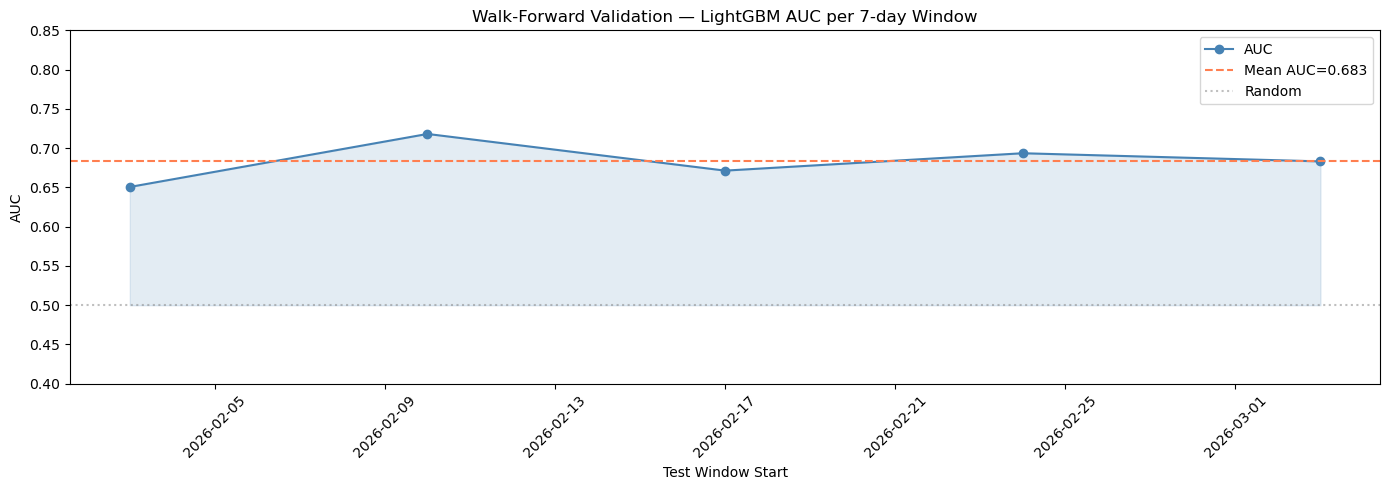


Stability: 5/5 windows with AUC > 0.55 (100%)


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wf_lgb['test_start'], wf_lgb['auc'], 'o-', color='steelblue', label='AUC')
ax.axhline(y=wf_lgb['auc'].mean(), color='coral', linestyle='--', label=f'Mean AUC={wf_lgb["auc"].mean():.3f}')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
ax.fill_between(wf_lgb['test_start'], 0.5, wf_lgb['auc'], alpha=0.15, color='steelblue')

ax.set_xlabel('Test Window Start')
ax.set_ylabel('AUC')
ax.set_title('Walk-Forward Validation — LightGBM AUC per 7-day Window')
ax.legend()
ax.set_ylim(0.4, 0.85)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'walk_forward_auc.png'), dpi=150, bbox_inches='tight')
plt.show()

stable_windows = (wf_lgb['auc'] > 0.55).sum()
print(f'\nStability: {stable_windows}/{len(wf_lgb)} windows with AUC > 0.55 ({stable_windows/len(wf_lgb)*100:.0f}%)')

In [8]:
df_3c = df.copy()
df_3c = df_3c.sort_values('t0').reset_index(drop=True)
label_map = {-1: 0, 0: 1, 1: 2}
df_3c['y3'] = df_3c['label'].map(label_map)

print(f'3-class distribution:')
for label_name, code in [('SL', 0), ('Vertical', 1), ('TP', 2)]:
    count = (df_3c['y3'] == code).sum()
    print(f'  {label_name} ({code}): {count:,} ({count/len(df_3c)*100:.1f}%)')

n3 = len(df_3c)
train_end3 = int(n3 * 0.70)
val_end3 = int(n3 * 0.85)

train3 = df_3c.iloc[:train_end3]
val3 = df_3c.iloc[train_end3:val_end3]
test3 = df_3c.iloc[val_end3:]

X_train3, y_train3 = train3[FEATURES].values, train3['y3'].values
X_val3, y_val3 = val3[FEATURES].values, val3['y3'].values
X_test3, y_test3 = test3[FEATURES].values, test3['y3'].values

medians3 = np.nanmedian(X_train3, axis=0)
for i in range(X_train3.shape[1]):
    X_train3[np.isnan(X_train3[:, i]), i] = medians3[i]
    X_val3[np.isnan(X_val3[:, i]), i] = medians3[i]
    X_test3[np.isnan(X_test3[:, i]), i] = medians3[i]

print(f'\nTrain: {len(train3):,} | Val: {len(val3):,} | Test: {len(test3):,}')

3-class distribution:
  SL (0): 17,546 (40.4%)
  Vertical (1): 8,378 (19.3%)
  TP (2): 17,537 (40.4%)

Train: 30,422 | Val: 6,519 | Test: 6,520


3-Class LightGBM on test:
Accuracy: 0.5256
              precision    recall  f1-score   support

          SL       0.53      0.58      0.55      2620
    Vertical       0.44      0.26      0.33      1241
          TP       0.54      0.59      0.57      2659

    accuracy                           0.53      6520
   macro avg       0.50      0.48      0.48      6520
weighted avg       0.52      0.53      0.52      6520



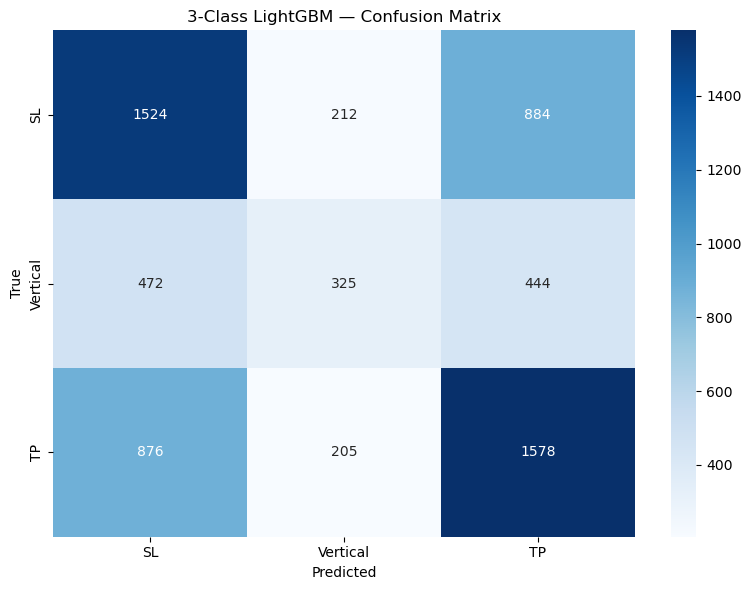

In [9]:
lgb_params_3c = lgb_params.copy()
lgb_params_3c['objective'] = 'multiclass'
lgb_params_3c['num_class'] = 3

lgb_3c = lgb.LGBMClassifier(**lgb_params_3c)
lgb_3c.fit(X_train3, y_train3, eval_set=[(X_val3, y_val3)])

y_pred_3c = lgb_3c.predict(X_test3)
y_prob_3c = lgb_3c.predict_proba(X_test3)

acc_3c = accuracy_score(y_test3, y_pred_3c)

print(f'3-Class LightGBM on test:')
print(f'Accuracy: {acc_3c:.4f}')
print(classification_report(y_test3, y_pred_3c, target_names=['SL', 'Vertical', 'TP']))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test3, y_pred_3c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['SL', 'Vertical', 'TP'], yticklabels=['SL', 'Vertical', 'TP'])
ax.set_title('3-Class LightGBM — Confusion Matrix')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(str(MODELS_DIR / '3class_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
thresholds = [0.0, 0.3, 0.4, 0.5]

test3_bin_mask = test3['label'] != 0
test3_bin = test3[test3_bin_mask]

X_test3_bin = test3_bin[FEATURES].values
for i in range(X_test3_bin.shape[1]):
    X_test3_bin[np.isnan(X_test3_bin[:, i]), i] = train_medians[i]
y_test3_bin = (test3_bin['label'] == 1).astype(int).values

lgb_prob_all = lgb_model.predict_proba(X_test3_bin)[:, 1]
p_vertical = y_prob_3c[test3_bin_mask.values, 1]

print(f'{"Threshold":>10s} | {"Samples":>8s} | {"AUC":>8s} | {"Acc":>8s} | {"Coverage":>8s}')
print('-' * 55)

for thr in thresholds:
    mask = p_vertical < thr if thr > 0 else np.ones(len(p_vertical), dtype=bool)
    if mask.sum() < 50:
        continue

    y_te_f = y_test3_bin[mask]
    y_prob_f = lgb_prob_all[mask]
    y_pred_f = (y_prob_f > 0.5).astype(int)

    auc_f = roc_auc_score(y_te_f, y_prob_f) if len(np.unique(y_te_f)) > 1 else 0.5
    acc_f = accuracy_score(y_te_f, y_pred_f)
    coverage = mask.sum() / len(mask)

    label = 'ALL' if thr == 0 else f'P(V)<{thr}'
    print(f'{label:>10s} | {mask.sum():>8d} | {auc_f:8.4f} | {acc_f:8.4f} | {coverage:8.1%}')

print('\n→ Filtering out high P(vertical) can improve precision by focusing on actionable trades')

 Threshold |  Samples |      AUC |      Acc | Coverage
-------------------------------------------------------
       ALL |     5279 |   0.6782 |   0.6441 |   100.0%
  P(V)<0.3 |     4378 |   0.6728 |   0.6398 |    82.9%
  P(V)<0.4 |     4927 |   0.6739 |   0.6406 |    93.3%
  P(V)<0.5 |     5175 |   0.6758 |   0.6421 |    98.0%

→ Filtering out high P(vertical) can improve precision by focusing on actionable trades


In [11]:
print('='*70)
print('FINAL MODEL COMPARISON (Test Set)')
print('='*70)

summary = {}

for name in ['XGB raw', 'XGB Platt', 'XGB Isotonic', 'LGB raw', 'LGB Platt', 'LGB Isotonic']:
    summary[name] = cal_results[name]

for name in ['Soft Voting', 'Weighted Avg', 'Stacking (LR)']:
    summary[name] = ens_results[name]

summary['LGB Walk-Forward'] = {
    'auc': wf_lgb['auc'].mean(),
    'accuracy': wf_lgb['accuracy'].mean(),
    'brier': None,
    'logloss': None,
}

summary_df = pd.DataFrame(summary).T
print(summary_df[['auc', 'accuracy', 'brier', 'logloss']].round(4).to_string())

best_name = summary_df['auc'].idxmax()
print(f'\nBest model by AUC: {best_name} (AUC={summary_df.loc[best_name, "auc"]:.4f})')

brier_df = summary_df.dropna(subset=['brier'])
best_cal_name = brier_df['brier'].idxmin()
print(f'Best calibration: {best_cal_name} (Brier={brier_df.loc[best_cal_name, "brier"]:.4f})')

FINAL MODEL COMPARISON (Test Set)
                     auc  accuracy   brier  logloss
XGB raw           0.6767    0.6373  0.2282   0.6497
XGB Platt         0.6767    0.6382  0.2270   0.6462
XGB Isotonic      0.6758    0.6348  0.2294   0.6545
LGB raw           0.6777    0.6437  0.2274   0.6481
LGB Platt         0.6777    0.6435  0.2267   0.6456
LGB Isotonic      0.6771    0.6411  0.2288   0.6533
Soft Voting       0.6783    0.6401  0.2274   0.6478
Weighted Avg      0.6781    0.6386  0.2275   0.6482
Stacking (LR)     0.6781    0.6386  0.2268   0.6458
LGB Walk-Forward  0.6833    0.6346     NaN      NaN

Best model by AUC: LGB Walk-Forward (AUC=0.6833)
Best calibration: LGB Platt (Brier=0.2267)


In [12]:
best_cal_name = best_cal[0]

joblib.dump(xgb_model, MODELS_DIR / 'xgb_model_v2.joblib')
joblib.dump(lgb_model, MODELS_DIR / 'lgb_model_v2.joblib')

calibrators = {
    'platt_xgb': platt_xgb,
    'platt_lgb': platt_lgb,
    'iso_xgb': iso_xgb,
    'iso_lgb': iso_lgb,
}
joblib.dump(calibrators, MODELS_DIR / 'calibrators_v2.joblib')

joblib.dump(lgb_3c, MODELS_DIR / 'lgb_3class_v1.joblib')

ensemble_meta = {
    'weighted_avg_weight_xgb': float(best_w),
    'stacking_coef_xgb': float(meta_lr.coef_[0][0]),
    'stacking_coef_lgb': float(meta_lr.coef_[0][1]),
    'stacking_intercept': float(meta_lr.intercept_[0]),
}
joblib.dump(meta_lr, MODELS_DIR / 'stacking_meta_lr_v1.joblib')

model_meta_v2 = {
    'best_calibrated_model': best_cal_name,
    'best_binary_auc_test': float(cal_results[best_cal_name]['auc']),
    'best_binary_brier_test': float(cal_results[best_cal_name]['brier']),
    'walk_forward_auc_mean': float(wf_lgb['auc'].mean()),
    'walk_forward_auc_std': float(wf_lgb['auc'].std()),
    'walk_forward_windows': len(wf_lgb),
    'ensemble': ensemble_meta,
    '3class_accuracy_test': float(acc_3c),
    'features': FEATURES,
    'n_features': len(FEATURES),
    'seed': SEED,
    'all_test_results': {k: {m: round(v, 4) for m, v in vals.items()} for k, vals in cal_results.items()},
}

with open(MODELS_DIR / 'model_meta_v2.json', 'w') as f:
    json.dump(model_meta_v2, f, indent=2, default=str)

print('Saved:')
for p in ['xgb_model_v2.joblib', 'lgb_model_v2.joblib', 'calibrators_v2.joblib',
          'lgb_3class_v1.joblib', 'stacking_meta_lr_v1.joblib', 'model_meta_v2.json']:
    path = MODELS_DIR / p
    print(f'  {path}')

Saved:
  ../../data/models/xgb_model_v2.joblib
  ../../data/models/lgb_model_v2.joblib
  ../../data/models/calibrators_v2.joblib
  ../../data/models/lgb_3class_v1.joblib
  ../../data/models/stacking_meta_lr_v1.joblib
  ../../data/models/model_meta_v2.json
